Mounted at /content/drive
Project Root impostato su: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab
Models Directory: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/models
Features Directory: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/data/processed/features_v2
CSV Path: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/data/raw/UrbanSound8K.csv

[FASE 1/5] Caricamento di tutti i dati delle feature...

[FASE 1/5] Caricamento di tutti i dati delle feature...
Caricando fold1 per log_mel_spec...
Caricando fold10 per log_mel_spec...
Caricando fold2 per log_mel_spec...
Caricando fold3 per log_mel_spec...
Caricando fold4 per log_mel_spec...
Caricando fold5 per log_mel_spec...
Caricando fold6 per log_mel_spec...
Caricando fold7 per log_mel_spec...
Caricando fold8 per log_mel_spec...
Caricando fold9 per log_mel_spec...
Caricando fold1 per mfcc...
Caricando fold10 per mfcc...
Caricando fold2 per mfcc...
Caricando fold3 per mfcc...
Carican

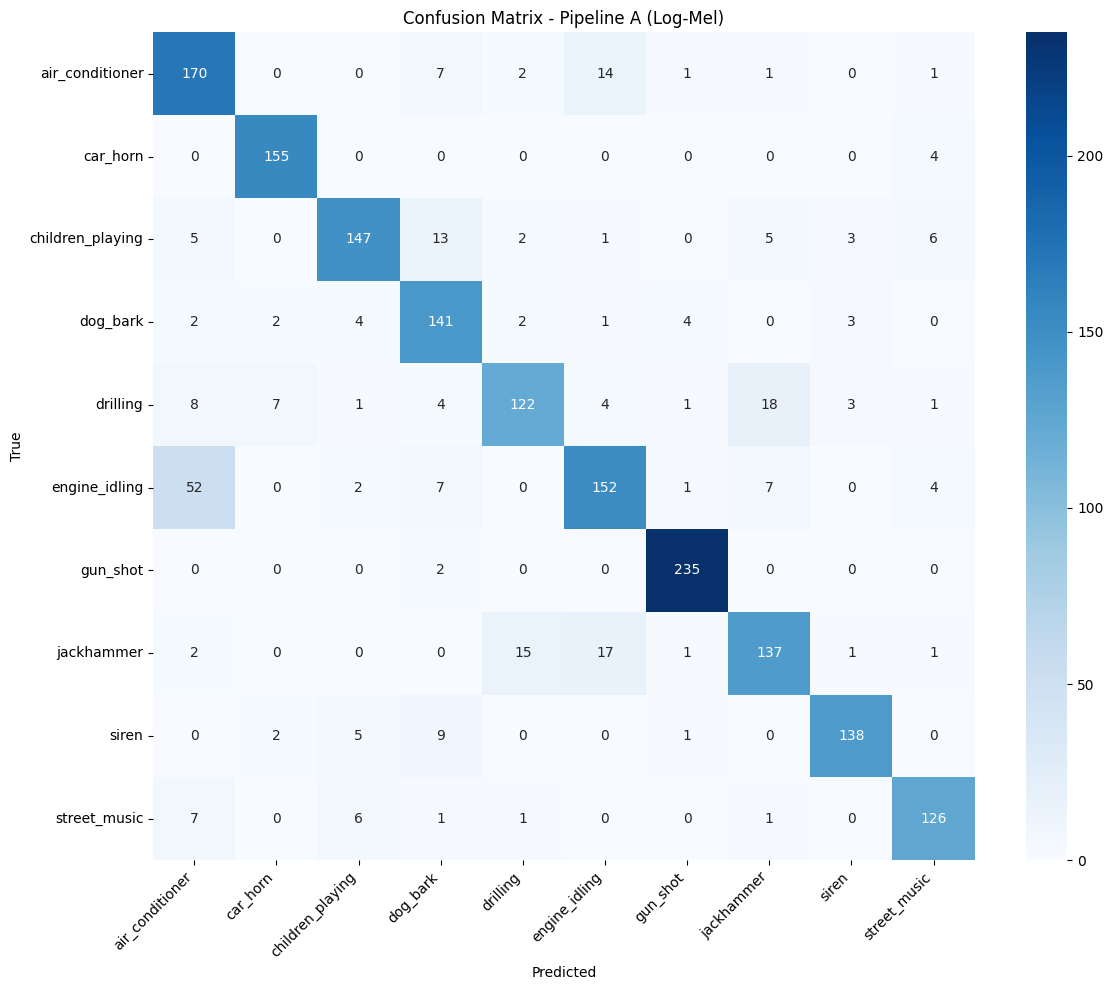

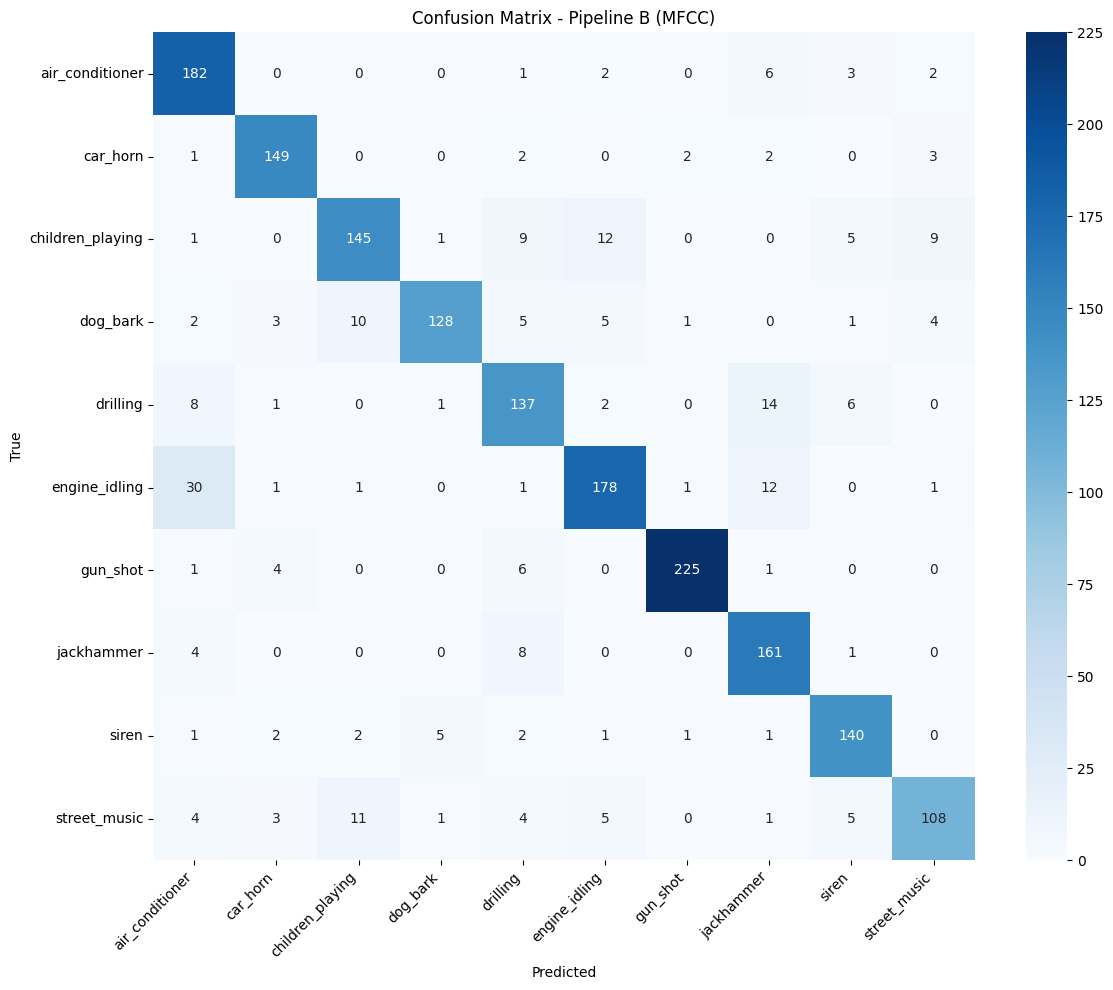

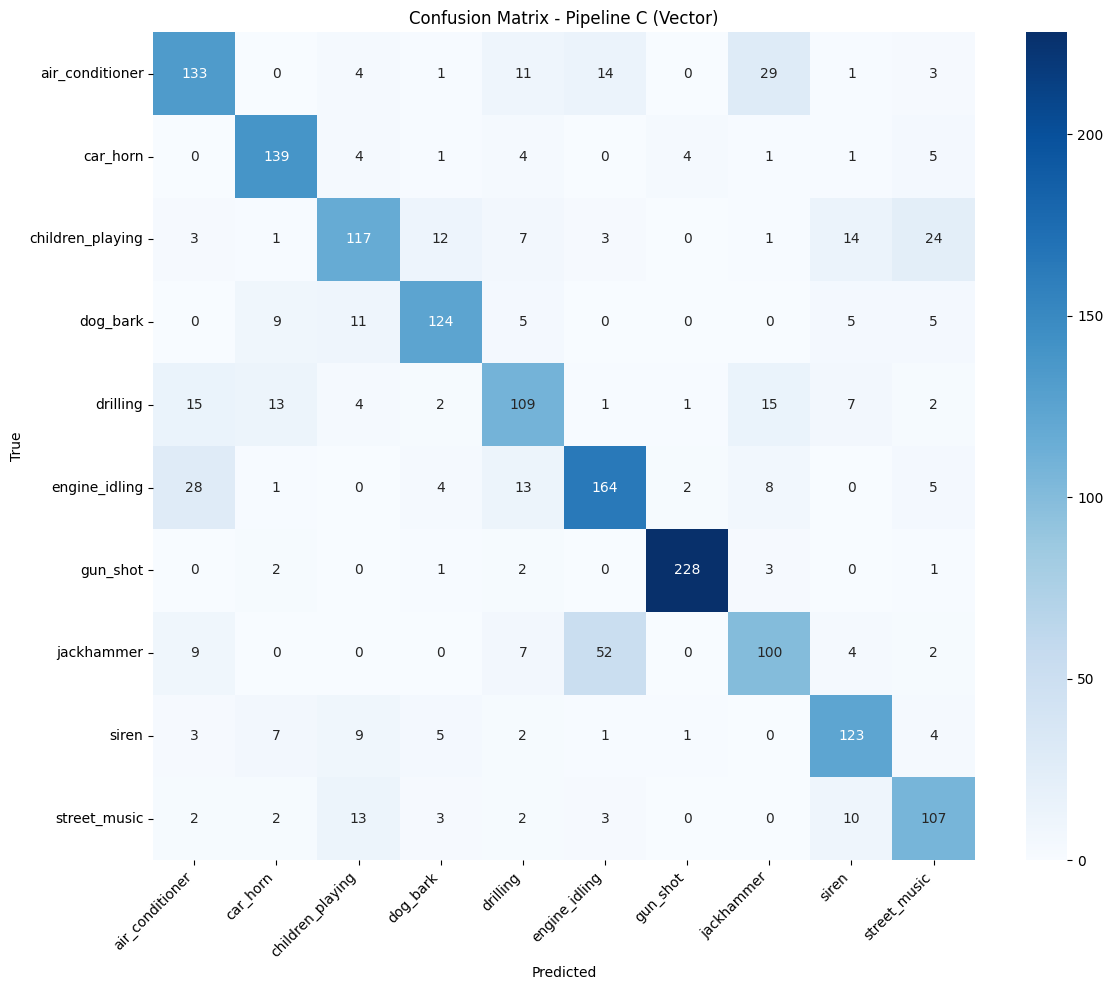

In [1]:
# notebooks/05_Final_Model_Comparison.ipynb

# --- 1. SETUP E CONFIGURAZIONE (CORRETTO PER GOOGLE COLAB) ---
import os
import sys
import json
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, accuracy_score, f1_score

# --- MODIFICHE PER COLAB ---

# 1. Monta Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 2. Trova il percorso radice del progetto
known_paths = [
    '/content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab', # Percorso Luke
    '/content/drive/MyDrive/Colab/urbanSmartSound_Colab'   # Percorso Mirko
]
PROJECT_ROOT = None
for path in known_paths:
    if os.path.exists(path):
        PROJECT_ROOT = path
        break

if not PROJECT_ROOT:
    raise FileNotFoundError("ERRORE: Nessuno dei percorsi di progetto conosciuti è stato trovato.")

print(f"Project Root impostato su: {PROJECT_ROOT}")
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Importa i moduli personalizzati
from src import data_loader, evaluation

# === DEFINIZIONE DEI PERCORSI ROBUSTI ===
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
FEATURES_DIR = os.path.join(PROJECT_ROOT, "data/processed/features_v2") # Assicurati che sia la cartella corretta
CSV_PATH = os.path.join(PROJECT_ROOT, "data/raw/UrbanSound8K.csv")
# =========================================

print(f"Models Directory: {MODELS_DIR}")
print(f"Features Directory: {FEATURES_DIR}")
print(f"CSV Path: {CSV_PATH}")

# --- 2. CARICAMENTO DATI GLOBALE E SPLIT DI TEST ---
print("\n[FASE 1/5] Caricamento di tutti i dati delle feature...")
print("\n[FASE 1/5] Caricamento di tutti i dati delle feature...")

def load_data_for_pipeline(loader_fn, **kwargs):
    """Funzione helper per caricare i dati di tutti i fold."""
    all_data = {}
    fold_dirs = sorted(glob.glob(os.path.join(FEATURES_DIR, "fold*")))
    for fold_dir in fold_dirs:
        fold_name = os.path.basename(fold_dir)
        print(f"Caricando {fold_name} per {kwargs.get('feature_key', 'vector')}...")
        X_fold, y_fold = data_loader.collect_fold_data(
            fold_dir, loader_fn, **kwargs
        )
        all_data[fold_name] = (X_fold, y_fold)
    return all_data

all_data_logmel = load_data_for_pipeline(data_loader.load_feature, feature_key='log_mel_spec')
all_data_mfcc = load_data_for_pipeline(data_loader.load_feature, feature_key='mfcc')
all_data_vector = load_data_for_pipeline(data_loader.load_vector_features)
print("Caricamento dati completato.")

print("\n[FASE 2/5] Creazione del set di test stratificato...")
# Usiamo la funzione di split per ottenere lo stesso set di test per tutti.
# Passiamo il percorso CSV e usiamo i dati log-mel come riferimento per lo split.
# Lo split è basato su fsID, quindi i dati (X) possono essere sostituiti.
_, _, X_test_logmel, y_test = data_loader.get_train_test_split_from_folds(
    all_data_logmel,
    meta_file_path=CSV_PATH,
    test_size=0.2,
    random_state=42
)
_, _, X_test_mfcc, _ = data_loader.get_train_test_split_from_folds(
    all_data_mfcc,
    meta_file_path=CSV_PATH,
    test_size=0.2,
    random_state=42
)
_, _, X_test_vector, _ = data_loader.get_train_test_split_from_folds(
    all_data_vector,
    meta_file_path=CSV_PATH,
    test_size=0.2,
    random_state=42
)
print(f"Dimensioni del set di test: {X_test_logmel.shape[0]} campioni.")

# --- 3. CARICAMENTO MODELLI E PREDIZIONI ---
print("\n[FASE 3/5] Caricamento modelli e esecuzione predizioni...")

models_to_evaluate = {
    "Pipeline A (Log-Mel)": {
        "model_path": os.path.join(MODELS_DIR, "model_A_logmel.keras"),
        "test_data": X_test_logmel
    },
    "Pipeline B (MFCC)": {
        "model_path": os.path.join(MODELS_DIR, "model_B_mfcc.keras"),
        "test_data": X_test_mfcc
    },
    "Pipeline C (Vector)": {
        "model_path": os.path.join(MODELS_DIR, "model_C_vector.keras"),
        "test_data": X_test_vector
    }
}

results = {}
for name, info in models_to_evaluate.items():
    print(f"  - Elaborazione: {name}")
    model = tf.keras.models.load_model(info["model_path"])
    y_pred = np.argmax(model.predict(info["test_data"], verbose=0), axis=1)
    results[name] = {"y_pred": y_pred}

# Carica i nomi delle classi per i report
class_names = data_loader.get_class_map(csv_path=CSV_PATH)
print("Predizioni completate.")

# --- 4. VALUTAZIONE COMPLETA E TABELLA RIASSUNTIVA ---
print("\n\n" + "="*50)
print("--- [FASE 4/5] REPORT DI VALUTAZIONE COMPLETO ---")
print("="*50)

summary_data = []
for name, data in results.items():
    acc = accuracy_score(y_test, data['y_pred'])
    f1 = f1_score(y_test, data['y_pred'], average='weighted')
    summary_data.append({"Pipeline": name, "Accuracy": f"{acc:.4f}", "F1-Score (Weighted)": f"{f1:.4f}"})

    print(f"\n\n--- Performance Dettagliata per: {name} ---")
    # Stampa il report di classificazione completo
    report = classification_report(y_test, data['y_pred'], target_names=class_names)
    print(report)

print("\n\n" + "="*50)
print("--- TABELLA RIASSUNTIVA DELLE PERFORMANCE SUL TEST SET ---")
print("="*50)
df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))


# --- 5. VISUALIZZAZIONE MATRICI DI CONFUSIONE ---
print("\n\n" + "="*50)
print("--- [FASE 5/5] MATRICI DI CONFUSIONE ---")
print("="*50 + "\n")

for name, data in results.items():
    evaluation.plot_confusion_matrix(
        y_test,
        data['y_pred'],
        class_names,
        title=f"Confusion Matrix - {name}"
    )

In [ ]:
from google.colab import drive
drive.mount('/content/drive')